# Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.data_loader import find_repo_root
from sklearn.metrics import r2_score
from datetime import datetime
from sklearn.preprocessing import StandardScaler

# Settings

In [2]:
sampling_rate = '5min'
columns_needed = ['time', 'orbital_decay', 'trend','|avg B|', 'F10.7 (LASP)', 'Bz GSE', 'Flow Speed (km/s', 'Temperature (K)', 'Kp (LASP)', 'median_decay_last_7D', 'median_decay_last_14D', 'median_decay_last_30D']
target = 'trend'
# ---- forecast parameters ----
n = 12  # hours ahead
m = 15  # minutes steps

# Load Data

In [3]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns_needed)
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))



X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X = pd.read_parquet(X_file)
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y = pd.read_parquet(y_file)

✅ Successfully loaded data with shape: (210528, 11)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)', 'Bz GSE', 'Flow Speed (km/s', 'Temperature (K)', 'Kp (LASP)', 'median_decay_last_7D', 'median_decay_last_14D', 'median_decay_last_30D']
Sample rate: 5min


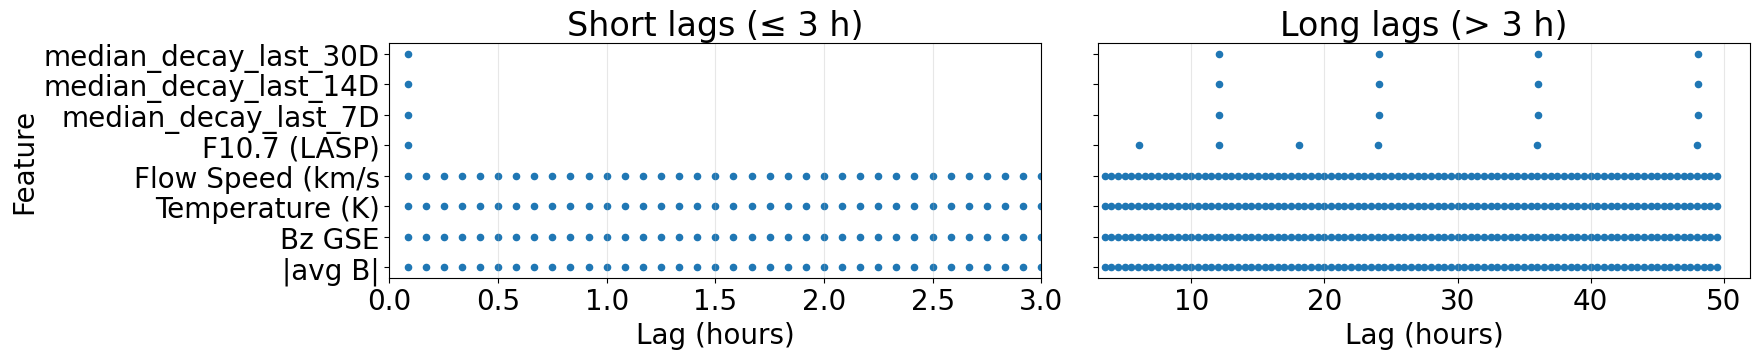

In [10]:
# masks

active_lag_names = X.columns

# --- build dataframes ---
df_active = (
    active_lag_names
    .to_series(name="coef")
    .str.extract(r'^(?P<feature>.+?)_lag_(?P<lag>\d+)$')
    .assign(lag=lambda d: d["lag"].astype(int))
)
# combine feature order from both
feature_order =df_active["feature"].unique()
feature_to_y = {f: i for i, f in enumerate(feature_order)}

# map y
df_active["y"] = df_active["feature"].map(feature_to_y)

# convert to hours (5 min resolution)
df_active["hours"] = df_active["lag"] * 5 / 60

# split
h_split = 3

mask_short_a = df_active["hours"] <= h_split
mask_long_a  = df_active["hours"] > h_split

plt.rcParams.update({'font.size': 20})
# --- plotting ---
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(18, 0.5 * len(feature_order)),
    gridspec_kw={"width_ratios": [1, 1]}
)

# LEFT panel
ax1.scatter(df_active.loc[mask_short_a, "hours"],
            df_active.loc[mask_short_a, "y"],
            s=20)

ax1.set_xlim(0, h_split)
ax1.set_xlabel("Lag (hours)")
ax1.set_title("Short lags (≤ 3 h)")
ax1.grid(axis="x", alpha=0.3)

# RIGHT panel
ax2.scatter(df_active.loc[mask_long_a, "hours"],
            df_active.loc[mask_long_a, "y"],
            s=20)


ax2.set_xlim(h_split, df_active["hours"].max() * 1.05)
ax2.set_xlabel("Lag (hours)")
ax2.set_title("Long lags (> 3 h)")
ax2.grid(axis="x", alpha=0.3)

# y-axis
ax1.set_yticks(range(len(feature_order)))
ax1.set_yticklabels(feature_order)
ax1.set_ylabel("Feature")

# fig.suptitle(f"Active (blue) vs Inactive (red) Lags — {target} | {number} | α = {Alpha}", y=1.02)

plt.tight_layout()
plt.show()